#### 데이터셋 생성

In [1]:
import sys
sys.path.insert(0, '.')
from dvw_batch_pipeline import run_batch
import pandas as pd

TARGET_SETTERS = {
    '대한항공': [2], '현대캐피탈': [3, 20], '우리카드': [2], 'KB손해보험': [2],
    '한국전력': [6], 'OK저축은행': [6], '삼성화재': [2, 3],
}

FOLDER = r'C:\Users\SB99\Documents\volleyball_analysis\data\2025-2026 V-League(M)\Scout'

final_df, errors = run_batch(
    folder_path=FOLDER,
    target_setters=TARGET_SETTERS,
    pattern='*_M*.dvw',     # 라운드 제한 없이 M01~M21 전부
    season_stats_csv='season_attack_stats.csv',
    verbose=True,           # 126개 처리되는 걸 실시간으로 확인
)

print(final_df.shape)
print("처리된 파일 수:", final_df['source_file'].nunique())

# 에러/스킵 로그 확인
for e in errors:
    print(e['file'], '->', e['error'])

총 126개 파일 발견
[1/126] &[20251020_1R_M01] 한국전력 vs 우리카드_건희(수현 완).dvw -> 75행
[2/126] &[20251021_1R_M02] 삼성화재 vs OK저축은행_연아(광연 완).dvw -> 209행
[3/126] &[20251022_1R_M03] 현대캐피탈 vs KB손해보험_지현(민수 완).dvw -> 200행
[4/126] &[20251023_1R_M04] 대한항공 vs 한국전력_건희(수현 완).dvw -> 145행
[5/126] &[20251024_1R_M05] 우리카드 vs OK저축은행_진솔(완).dvw -> 195행
[6/126] &[20251025_1R_M06] 삼성화재 vs 현대캐피탈_연아(완).dvw -> 163행
[7/126] &[20251026_1R_M07] KB손해보험 vs 대한항공_도윤(진솔 완).dvw -> 163행
[8/126] &[20251028_1R_M08] 우리카드 vs 삼성화재_민수(광연 완).dvw -> 114행
[9/126] &[20251029_1R_M09] 한국전력 vs 현대캐피탈_지현(도윤 완).dvw -> 180행
[10/126] &[20251030_1R_M10] KB손해보험 vs OK저축은행_진솔(완).dvw -> 147행
[11/126] &[20251031_1R_M11] 대한항공 vs 우리카드_도윤(광연 완).dvw -> 120행
[12/126] &[20251101_1R_M12] 한국전력 vs 삼성화재_지현(연아 완).dvw -> 179행
[13/126] &[20251102_1R_M13] 현대캐피탈 vs OK저축은행_지현(수현 완).dvw -> 152행
[14/126] &[20251104_1R_M14] KB손해보험 vs 우리카드_수현(광연 완).dvw -> 133행
[15/126] &[20251105_1R_M15] 삼성화재 vs 대한항공_지현(도윤 완).dvw -> 168행
[16/126] &[20251106_1R_M16] 한국전력 vs OK저축은행_건희(진솔 완).dvw 

In [2]:
# # 1. 팀명이 7개로 정상적으로 다 나오는지 (다른 라운드에서 또 구단명 바뀐 팀 있는지)
# print(final_df['team'].value_counts())

# # 2. 시즌 데이터 결측 여부 (구단명 안 맞으면 여기서 NaN 튐)
# print(final_df[['attacker_season_pct', 'ace_is_front']].isna().sum())

# # 3. 경기당 행 수 분포 (극단적으로 적거나 많은 경기 있는지)
# print(final_df.groupby('source_file', sort=False).size().describe())

In [3]:
# final_df.to_csv('final_dataset.csv', index=False, encoding='utf-8-sig')

#### 세터별 섀넌 엔트로피 계산

In [4]:
import re
import numpy as np
import pandas as pd
from scipy.stats import entropy

df = final_df.copy()

# ============================================================
# 1. player_id에서 등번호 추출 (하이픈/언더스코어 표기 차이 무시)
# ============================================================
def get_jersey_number(player_id):
    if pd.isna(player_id):
        return None
    m = re.search(r'[-_](\d+)$', str(player_id))
    if not m:
        return None
    return int(m.group(1)[-2:])

df['setter_number'] = df['setter'].apply(get_jersey_number)

# ============================================================
# 2. 확정된 9인 세터 (team, 등번호, 이름)
# ============================================================
FINAL_SETTERS = [
    ('OK저축은행', 6, '이민규'),
    ('우리카드', 2, '한태준'),
    ('KB손해보험', 2, '황택의'),
    ('한국전력', 6, '하승우'),
    ('대한항공', 2, '한선수'),
    ('현대캐피탈', 3, '황승빈'),
    ('삼성화재', 2, '도산지'),
    ('삼성화재', 3, '노재욱'),
    ('현대캐피탈', 20, '이준협'),
]
setter_lookup = {(team, num): name for team, num, name in FINAL_SETTERS}
valid_keys = set(setter_lookup.keys())

mask = df.apply(lambda r: (r['team'], r['setter_number']) in valid_keys, axis=1)
df_final = df[mask].copy()
df_final['setter_canonical'] = df_final.apply(lambda r: f"{r['team']}_{int(r['setter_number'])}", axis=1)
df_final['setter_name'] = df_final.apply(lambda r: setter_lookup[(r['team'], r['setter_number'])], axis=1)

print('필터링 후 세터 수:', df_final['setter_canonical'].nunique(), '/ 목표 9명\n')

# ============================================================
# 3. attack_code 희소 클래스 Other로 묶기
# ============================================================
THRESHOLD = 50
vc = df_final['attack_code'].value_counts()
rare_codes = vc[vc < THRESHOLD].index.tolist()
df_final['attack_code_grouped'] = df_final['attack_code'].where(~df_final['attack_code'].isin(rare_codes), 'Other')

# ============================================================
# 4. 두 가지 방법으로 엔트로피 계산 + 정규화
# ============================================================
def setter_entropy(series):
    probs = series.value_counts(normalize=True)
    return entropy(probs, base=2)

entropy_zone = df_final.groupby('setter_canonical')['attack_zone'].apply(setter_entropy)
entropy_code = df_final.groupby('setter_canonical')['attack_code_grouped'].apply(setter_entropy)

name_map = df_final.drop_duplicates('setter_canonical').set_index('setter_canonical')['setter_name']

result = pd.DataFrame({
    'name': name_map,
    'entropy_zone': entropy_zone,
    'entropy_zone_norm': entropy_zone / np.log2(df_final['attack_zone'].nunique()),
    'entropy_code': entropy_code,
    'entropy_code_norm': entropy_code / np.log2(df_final['attack_code_grouped'].nunique()),
    'n_tosses': df_final.groupby('setter_canonical').size(),
}).sort_values('entropy_zone_norm', ascending=False)

pd.set_option('display.float_format', '{:.3f}'.format)
print(result)

필터링 후 세터 수: 9 / 목표 9명

                 name  entropy_zone  entropy_zone_norm  entropy_code  \
setter_canonical                                                       
KB손해보험_2          황택의         2.174              0.841         3.073   
삼성화재_3            노재욱         2.169              0.839         3.042   
대한항공_2            한선수         2.163              0.837         2.974   
삼성화재_2            도산지         2.101              0.813         3.125   
OK저축은행_6          이민규         2.095              0.810         3.110   
우리카드_2            한태준         2.025              0.783         2.988   
현대캐피탈_20          이준협         2.002              0.775         2.830   
한국전력_6            하승우         1.996              0.772         3.105   
현대캐피탈_3           황승빈         1.987              0.769         2.892   

                  entropy_code_norm  n_tosses  
setter_canonical                               
KB손해보험_2                      0.807      2831  
삼성화재_3                        0.799     

#### 상황별 셰년 엔트로피 계산

In [5]:
import numpy as np
import pandas as pd
from scipy.stats import entropy

def setter_entropy(series):
    if len(series) < 2:
        return np.nan
    probs = series.value_counts(normalize=True)
    return entropy(probs, base=2)

def situational_entropy(df, situation_col, target_col='attack_zone', min_n=20):
    """
    세터 x 상황변수 별 엔트로피 계산.
    min_n: 이 값 미만인 칸은 NaN 처리 (표본 부족 경고용)
    """
    grouped = df.groupby(['setter_canonical', situation_col])
    result = grouped[target_col].agg(
        entropy=setter_entropy,
        n=('count')
    ).reset_index()
    result.loc[result['n'] < min_n, 'entropy'] = np.nan
    return result.pivot(index='setter_canonical', columns=situation_col, values='entropy')


# ============================================================
# 상황변수별 엔트로피표 (zone 기준, code_grouped로 바꾸려면 target_col 변경)
# ============================================================

# 1. 점수차 상황 (이기는 중 / 지는 중 / 비슷)
df_final['score_situation'] = pd.cut(
    df_final['score_diff'], bins=[-100, -3, 3, 100],
    labels=['지는중(-4이상)', '박빙(-3~3)', '이기는중(+4이상)']
)
print("=== 점수차 상황별 엔트로피 (zone) ===")
print(situational_entropy(df_final, 'score_situation').round(3))

# 2. 점수 스테이지 (1: 8점전, 2: 16점전, 3: 20점전, 4: 20점후)
print("\n=== 점수 스테이지별 엔트로피 (zone) ===")
print(situational_entropy(df_final, 'score_stage').round(3))

# 3. 클러치 상황 여부
print("\n=== 클러치 상황별 엔트로피 (zone) ===")
print(situational_entropy(df_final, 'is_clutch').round(3))

# 4. 사이드아웃 vs 브레이크포인트
print("\n=== 사이드아웃/브레이크포인트별 엔트로피 (zone) ===")
print(situational_entropy(df_final, 'point_type').round(3))

# 5. 세터 전위/후위
print("\n=== 세터 전위/후위별 엔트로피 (zone) ===")
print(situational_entropy(df_final, 'setter_front').round(3))

# ============================================================
# 표본 수도 같이 확인 (해석 신뢰도 판단용)
# ============================================================
print("\n=== 참고: 점수 스테이지별 표본 수 ===")
print(df_final.groupby(['setter_canonical', 'score_stage']).size().unstack())

=== 점수차 상황별 엔트로피 (zone) ===
score_situation   지는중(-4이상)  박빙(-3~3)  이기는중(+4이상)
setter_canonical                                 
KB손해보험_2              2.068     2.193       2.159
OK저축은행_6              2.091     2.095       2.076
대한항공_2                2.093     2.160       2.195
삼성화재_2                2.033     2.128       2.022
삼성화재_3                2.182     2.164       1.896
우리카드_2                2.011     2.030       1.984
한국전력_6                1.965     2.019       1.898
현대캐피탈_20              1.907     2.013       2.024
현대캐피탈_3               1.972     1.971       2.052

=== 점수 스테이지별 엔트로피 (zone) ===
score_stage          1     2     3     4
setter_canonical                        
KB손해보험_2         2.182 2.194 2.119 2.134
OK저축은행_6         2.080 2.082 2.119 2.096
대한항공_2           2.199 2.128 2.184 2.136
삼성화재_2           2.118 2.107 2.063 2.003
삼성화재_3           2.239 2.106 2.147 2.131
우리카드_2           2.001 1.988 2.033 2.085
한국전력_6           1.976 2.014 2.027 1.931
현대캐피탈_20         2.042 

C:\Users\SB99\AppData\Local\Temp\ipykernel_17184\1778055881.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(['setter_canonical', situation_col])


point_type        Breakpoint  Sideout
setter_canonical                     
KB손해보험_2               2.050    2.191
OK저축은행_6               1.920    2.122
대한항공_2                 2.066    2.177
삼성화재_2                 1.945    2.117
삼성화재_3                 1.900    2.192
우리카드_2                 1.923    2.036
한국전력_6                 1.759    2.019
현대캐피탈_20               1.831    2.017
현대캐피탈_3                1.899    1.990

=== 세터 전위/후위별 엔트로피 (zone) ===
setter_front         0     1
setter_canonical            
KB손해보험_2         1.837 1.805
OK저축은행_6         1.693 1.813
대한항공_2           1.800 1.841
삼성화재_2           1.802 1.597
삼성화재_3           1.828 1.805
우리카드_2           1.723 1.650
한국전력_6           1.680 1.619
현대캐피탈_20         1.871 1.648
현대캐피탈_3          1.806 1.682

=== 참고: 점수 스테이지별 표본 수 ===
score_stage         1     2    3    4
setter_canonical                     
KB손해보험_2          796   943  446  646
OK저축은행_6          874  1017  439  666
대한항공_2            739   816  361  458
삼성화재_2         

#### 모델 선정

In [6]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score, roc_auc_score, brier_score_loss
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# ============================================================
# 0. 데이터 준비 (df_final 기준, 9인 세터만)
# ============================================================
df = df_final.copy()

df['settercall_type'] = df['settercall_type'].fillna('None')
df['attacker_rt_eff_missing'] = df['attacker_rt_eff'].isna().astype(int)
df['attacker_rt_eff'] = df['attacker_rt_eff'].fillna(df['attacker_season_pct'])
df['is_repeat_route'] = pd.to_numeric(df['is_repeat_route'], errors='coerce').fillna(-1).astype(int)

nullable_cols = ['possession_num', 'consecutive_toss_count', 'opp_rotation', 'ace_is_front']
for c in nullable_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce').astype('float64')

df = df.dropna(subset=['attack_zone']).reset_index(drop=True)
df['attack_zone'] = df['attack_zone'].astype(str)

# ============================================================
# 1. 타깃 인코딩
# ============================================================
le_target = LabelEncoder()
y = le_target.fit_transform(df['attack_zone'])
n_classes = len(le_target.classes_)
print('클래스:', dict(zip(le_target.classes_, range(n_classes))))

# ============================================================
# 2. 독립변수 구성 (setter_canonical을 범주형 피처로 포함)
#    -> "이 세터가 이 상황에서 어디로 배분할지" 를 예측하는 모델
# ============================================================
cat_cols = ['first_touch', 'point_type', 'settercall_type', 'prev_attack_result', 'setter_canonical']
num_cols = ['score_diff', 'score_stage', 'is_clutch', 'streak_flow', 'possession_num',
            'opp_rotation', 'setter_front', 'attacker_rt_eff', 'attacker_rt_eff_missing',
            'is_repeat_route', 'consecutive_toss_count', 'touch_quality_score',
            'ace_is_front', 'attacker_season_pct']

feature_cols = cat_cols + num_cols
X_raw = df[feature_cols].copy()

for c in num_cols:
    X_raw[c] = pd.to_numeric(X_raw[c], errors='coerce')
    X_raw[c] = X_raw[c].fillna(X_raw[c].median())

for c in cat_cols:
    X_raw[c] = X_raw[c].astype(str).fillna('Unknown')

# RF/XGBoost용: 원-핫 인코딩
X_dummy = pd.get_dummies(X_raw, columns=cat_cols, drop_first=False)

groups = df['match_id']

# ============================================================
# 3. 모델별 성능 비교 (5-fold, 경기 단위 분리 + 클래스 균형)
# ============================================================
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'RandomForest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, objective='multi:softprob', num_class=n_classes,
                              eval_metric='mlogloss', random_state=42, n_jobs=-1),
}

results = {}
for name, model in models.items():
    f1_scores, auc_scores = [], []
    for train_idx, test_idx in sgkf.split(X_dummy, y, groups=groups):
        X_train, X_test = X_dummy.iloc[train_idx], X_dummy.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        proba = model.predict_proba(X_test)
        pred = model.predict(X_test)

        f1_scores.append(f1_score(y_test, pred, average='macro'))
        try:
            auc_scores.append(roc_auc_score(y_test, proba, multi_class='ovr', average='macro'))
        except ValueError:
            auc_scores.append(np.nan)  # 특정 fold에 없는 클래스 있을 때 대비

    results[name] = {'F1_macro': np.mean(f1_scores), 'ROC_AUC_macro': np.nanmean(auc_scores)}

# CatBoost는 범주형 그대로 (인코딩 없이)
cb_pool_cols = num_cols + cat_cols
X_cb = X_raw[cb_pool_cols].copy()
cat_feature_idx = [X_cb.columns.get_loc(c) for c in cat_cols]

f1_scores, auc_scores = [], []
for train_idx, test_idx in sgkf.split(X_cb, y, groups=groups):
    X_train, X_test = X_cb.iloc[train_idx], X_cb.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    cb_model = CatBoostClassifier(iterations=300, loss_function='MultiClass', random_seed=42,
                                   cat_features=cat_feature_idx, verbose=False)
    cb_model.fit(X_train, y_train)
    proba = cb_model.predict_proba(X_test)
    pred = cb_model.predict(X_test).flatten()

    f1_scores.append(f1_score(y_test, pred, average='macro'))
    try:
        auc_scores.append(roc_auc_score(y_test, proba, multi_class='ovr', average='macro'))
    except ValueError:
        auc_scores.append(np.nan)

results['CatBoost'] = {'F1_macro': np.mean(f1_scores), 'ROC_AUC_macro': np.nanmean(auc_scores)}

print("\n=== 모델 비교 (5-fold 평균) ===")
print(pd.DataFrame(results).T.round(4))

클래스: {'2': 0, '3': 1, '4': 2, '7': 3, '8': 4, '9': 5}


KeyboardInterrupt: 

#### BS 계산

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold
from catboost import CatBoostClassifier

# ============================================================
# 1. Out-of-fold 확률 예측 (CatBoost)
#    - 각 데이터가 "학습에 쓰이지 않은 fold"에서 나온 예측만 사용 -> 누수 방지
# ============================================================
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

oof_proba = np.zeros((len(y), n_classes))

for train_idx, test_idx in sgkf.split(X_cb, y, groups=groups):
    X_train, X_test = X_cb.iloc[train_idx], X_cb.iloc[test_idx]
    y_train = y[train_idx]

    cb_model = CatBoostClassifier(iterations=300, loss_function='MultiClass', random_seed=42,
                                   cat_features=cat_feature_idx, verbose=False)
    cb_model.fit(X_train, y_train)
    oof_proba[test_idx] = cb_model.predict_proba(X_test)

print("OOF 예측 완료. shape:", oof_proba.shape)

# ============================================================
# 2. Brier Score 계산 (토스 1건당)
#    BS_t = sum_c (p_tc - y_tc)^2   (계획서 수식 그대로, 다중분류이므로 각 클래스에 대해 합산)
# ============================================================
y_onehot = np.eye(n_classes)[y]  # 실제 선택을 원-핫으로
brier_per_toss = np.sum((oof_proba - y_onehot) ** 2, axis=1)

df['brier_score'] = brier_per_toss
df['predicted_class'] = le_target.inverse_transform(oof_proba.argmax(axis=1))
df['predicted_proba_max'] = oof_proba.max(axis=1)

print("\n전체 토스 평균 Brier Score:", brier_per_toss.mean().round(4))
print("Brier Score 분포:\n", pd.Series(brier_per_toss).describe())

# ============================================================
# 3. 세터별 예측불가능성 지표 (Brier Score 평균)
# ============================================================
bs_by_setter = df.groupby('setter_canonical').agg(
    brier_mean=('brier_score', 'mean'),
    n_tosses=('brier_score', 'size')
).sort_values('brier_mean', ascending=False)

name_map = df.drop_duplicates('setter_canonical').set_index('setter_canonical')['setter_name']
bs_by_setter['name'] = name_map
print("\n=== 세터별 예측불가능성(Brier Score, 높을수록 예측 어려움) ===")
print(bs_by_setter[['name', 'brier_mean', 'n_tosses']].round(4))

NameError: name 'y' is not defined

#### 세터별 예측 확률

In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# 1. 개별 토스 하나 예시로 실제 확률벡터 보기
# ============================================================
example_idx = 0
print("실제 선택:", le_target.inverse_transform([y[example_idx]])[0])
print("모델이 예측한 6개 zone 확률:")
for cls, prob in zip(le_target.classes_, oof_proba[example_idx]):
    print(f"  zone {cls}: {prob:.3f}")

# ============================================================
# 2. 전체 평균 예측확률 vs 실제 기저율(base rate) 비교
#    -> 모델이 그냥 "많이 나오는 zone에 항상 높은 확률"만 주는 건 아닌지 확인
# ============================================================
mean_pred_by_class = pd.Series(oof_proba.mean(axis=0), index=le_target.classes_)
actual_base_rate = pd.Series(y).value_counts(normalize=True).sort_index()
actual_base_rate.index = le_target.classes_

compare = pd.DataFrame({
    'model_avg_pred_prob': mean_pred_by_class,
    'actual_base_rate': actual_base_rate
})
print("\n=== 전체 평균: 모델 예측확률 vs 실제 기저율 ===")
print(compare.round(3))

# ============================================================
# 3. "실제로 선택된 클래스"에 모델이 준 확률 (Brier Score의 핵심 재료)
#    -> 이게 낮으면 그 토스는 모델이 전혀 예상 못한 선택이었다는 뜻
# ============================================================
prob_given_to_actual = oof_proba[np.arange(len(y)), y]
df['prob_given_to_actual_choice'] = prob_given_to_actual

print("\n전체 분포:")
print(pd.Series(prob_given_to_actual).describe())

# 세터별로 평균 -> "이 세터의 실제 선택에 모델이 평균 몇 %를 줬는가"
setter_prob = df.groupby('setter_canonical')['prob_given_to_actual_choice'].mean().sort_values()
name_map = df.drop_duplicates('setter_canonical').set_index('setter_canonical')['setter_name']
setter_prob_table = pd.DataFrame({'name': name_map, 'avg_prob_to_actual': setter_prob, 'brier_mean': setter_agg2['brier_mean']})
print("\n=== 세터별: 실제 선택에 모델이 준 평균 확률 (낮을수록 예측 못함) ===")
print(setter_prob_table.sort_values('avg_prob_to_actual').round(3))

# ============================================================
# 4. 세터별 "평균 예측 확률분포" 자체를 6개 zone으로 펼쳐서 보기
#    -> 이 세터에 대해 모델이 평소 어떤 zone에 확률을 많이 주는 경향이 있는지
# ============================================================
proba_df = pd.DataFrame(oof_proba, columns=[f'pred_{c}' for c in le_target.classes_])
proba_df['setter_canonical'] = df['setter_canonical'].values

setter_avg_proba = proba_df.groupby('setter_canonical').mean()
setter_avg_proba['name'] = name_map
print("\n=== 세터별 평균 예측확률 분포 (6개 zone) ===")
print(setter_avg_proba.round(3))

#### top-k accuracy 계산

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import top_k_accuracy_score

n_classes = len(le_target.classes_)  # 6

# ============================================================
# 1. 전체 Top-k 정확도 (k=1,2,3)
# ============================================================
print("=== 전체 Top-k 정확도 ===")
for k in range(1, n_classes):
    acc = top_k_accuracy_score(y, oof_proba, k=k, labels=np.arange(n_classes))
    print(f"Top-{k}: {acc:.4f}  ({acc*100:.1f}%)")

# 참고: 랜덤이면 top-k 정확도가 k/6이 나와야 함 (베이스라인 비교용)
print("\n랜덤 베이스라인 (k/6):")
for k in range(1, n_classes):
    print(f"Top-{k}: {k/n_classes:.4f}")

# ============================================================
# 2. 세터별 Top-k 정확도
# ============================================================
setter_topk = []
for setter, group_idx in df.groupby('setter_canonical').groups.items():
    idx = group_idx.values if hasattr(group_idx, 'values') else np.array(group_idx)
    y_sub = y[idx]
    proba_sub = oof_proba[idx]
    row = {'setter_canonical': setter, 'n': len(idx)}
    for k in [1, 2, 3]:
        try:
            row[f'top{k}_acc'] = top_k_accuracy_score(y_sub, proba_sub, k=k, labels=np.arange(n_classes))
        except ValueError:
            row[f'top{k}_acc'] = np.nan  # 해당 세터 데이터에 특정 클래스가 아예 없는 경우 등
    setter_topk.append(row)

setter_topk_df = pd.DataFrame(setter_topk).set_index('setter_canonical')
setter_topk_df['name'] = name_map
setter_topk_df = setter_topk_df.sort_values('top1_acc')

print("\n=== 세터별 Top-k 정확도 ===")
print(setter_topk_df[['name', 'n', 'top1_acc', 'top2_acc', 'top3_acc']].round(3))

#### 변수중요도 계산

In [ ]:
import pandas as pd
from catboost import CatBoostClassifier

# ============================================================
# 1. 전체 데이터로 최종 모델 학습 (변수중요도 산출용)
# ============================================================
final_model = CatBoostClassifier(
    iterations=300, loss_function='MultiClass', random_seed=42,
    cat_features=cat_feature_idx, verbose=False
)
final_model.fit(X_cb, y)

# ============================================================
# 2. 변수중요도 (PredictionValuesChange, CatBoost 기본 방식)
# ============================================================
importance = pd.DataFrame({
    'feature': X_cb.columns,
    'importance': final_model.get_feature_importance()
}).sort_values('importance', ascending=False)

print("=== 변수 중요도 (전체) ===")
print(importance.round(3))

# ============================================================
# 3. 범주형 vs 연속형 구분해서 보기 (해석 편의용)
# ============================================================
importance['type'] = importance['feature'].apply(
    lambda f: '범주형' if f in cat_cols else '연속형'
)
print("\n=== 유형별 중요도 합계 ===")
print(importance.groupby('type')['importance'].sum())

#### 변수 중요도 계산 (시즌 공격성공률 제외)

In [ ]:
exclude_cols = ['attacker_season_pct']

cat_cols_v2 = [c for c in cat_cols if c not in exclude_cols]
num_cols_v2 = [c for c in num_cols if c not in exclude_cols]
X_cb_v2 = X_raw[num_cols_v2 + cat_cols_v2].copy()
cat_feature_idx_v2 = [X_cb_v2.columns.get_loc(c) for c in cat_cols_v2]

model_v2 = CatBoostClassifier(iterations=300, loss_function='MultiClass', random_seed=42,
                               cat_features=cat_feature_idx_v2, verbose=False)
model_v2.fit(X_cb_v2, y)

importance_v2 = pd.DataFrame({
    'feature': X_cb_v2.columns,
    'importance': model_v2.get_feature_importance()
}).sort_values('importance', ascending=False)
print(importance_v2.round(3))

#### 모델 성능 비교 (시즌 공격 성공률 변수 유무)

In [ ]:
# v2 모델 성능 재확인 (5-fold CV로)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score, roc_auc_score

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
f1s, aucs = [], []
for train_idx, test_idx in sgkf.split(X_cb_v2, y, groups=groups):
    m = CatBoostClassifier(iterations=300, loss_function='MultiClass', random_seed=42,
                            cat_features=cat_feature_idx_v2, verbose=False)
    m.fit(X_cb_v2.iloc[train_idx], y[train_idx])
    proba = m.predict_proba(X_cb_v2.iloc[test_idx])
    pred = m.predict(X_cb_v2.iloc[test_idx]).flatten()
    f1s.append(f1_score(y[test_idx], pred, average='macro'))
    aucs.append(roc_auc_score(y[test_idx], proba, multi_class='ovr', average='macro'))

print(f"v2 모델: F1={np.mean(f1s):.4f}, AUC={np.mean(aucs):.4f}")
print(f"v1 모델(참고): F1=0.660, AUC=0.934")

#### 세터별 예측 불가능성 지수 - 공격 성공 상관 

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import pointbiserialr, spearmanr

# ============================================================
# 0. 공격 성공 여부 정의 (킬 = '#' 만 성공으로, 지난번 attacker_rt_eff 계산과 동일 기준)
# ============================================================
df['attack_success'] = (df['attack_result'] == '#').astype(int)

print("전체 공격 성공률:", df['attack_success'].mean().round(4))

# ============================================================
# 1. 토스(개별 공) 단위 상관관계
#    - point-biserial: 연속형(BS) vs 이진형(성공/실패)
# ============================================================
valid = df[['brier_score', 'attack_success']].dropna()

r_pb, p_pb = pointbiserialr(valid['attack_success'], valid['brier_score'])
print(f"\n[토스 단위] Point-biserial r = {r_pb:.4f}, p = {p_pb:.4g}, n = {len(valid)}")

# 참고: 성공/실패 그룹별 BS 평균 비교
print(valid.groupby('attack_success')['brier_score'].agg(['mean', 'median', 'std', 'count']))

# ============================================================
# 2. 세터 단위 상관관계 (9명, Spearman)
#    - "예측불가능성이 높은 세터일수록 그 세터가 만든 공격의 성공률도 높은가?"
# ============================================================
setter_agg = df.groupby('setter_canonical').agg(
    brier_mean=('brier_score', 'mean'),
    attack_success_rate=('attack_success', 'mean'),
    n_tosses=('brier_score', 'size')
)
setter_agg['name'] = df.drop_duplicates('setter_canonical').set_index('setter_canonical')['setter_name']

rho, p_rho = spearmanr(setter_agg['brier_mean'], setter_agg['attack_success_rate'])
print(f"\n[세터 단위, n=9] Spearman rho = {rho:.4f}, p = {p_rho:.4g}")
print(setter_agg[['name', 'brier_mean', 'attack_success_rate', 'n_tosses']]
      .sort_values('brier_mean', ascending=False).round(4))

#### 셰넌 엔트로피 지수 - 공격 성공률 상관

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, entropy

# ============================================================
# 1. 세터 단위 (n=9) - 지금까지 쓰던 entropy_zone_norm 그대로 사용
# ============================================================
entropy_zone_norm = entropy_zone / np.log2(df['attack_zone'].nunique())  # 이전 계산 재사용

setter_agg2 = setter_agg.copy()
setter_agg2['entropy_norm'] = entropy_zone_norm

rho9, p9 = spearmanr(setter_agg2['entropy_norm'], setter_agg2['attack_success_rate'])
print(f"[세터 단위, n=9] entropy vs 성공률: Spearman rho={rho9:.4f}, p={p9:.4g}")
print(setter_agg2[['name', 'entropy_norm', 'brier_mean', 'attack_success_rate', 'n_tosses']]
      .sort_values('entropy_norm', ascending=False).round(4))

# ============================================================
# 2. 세터 x 경기 단위 (표본 확대 버전)
#    - 각 세터가 각 경기에서 보인 엔트로피 vs 그 경기에서의 공격 성공률
#    - 경기당 토스 수가 너무 적으면 엔트로피 추정이 불안정하므로 최소 표본 필터링
# ============================================================
MIN_TOSSES_PER_MATCH = 15  # 이 값 미만인 경기는 제외 (조정 가능)

def match_entropy(series):
    if len(series) < 2:
        return np.nan
    probs = series.value_counts(normalize=True)
    return entropy(probs, base=2)

match_level = df.groupby(['setter_canonical', 'match_id']).agg(
    entropy=('attack_zone', match_entropy),
    success_rate=('attack_success', 'mean'),
    n_tosses=('attack_zone', 'size')
).reset_index()

match_level = match_level[match_level['n_tosses'] >= MIN_TOSSES_PER_MATCH].dropna()

n_zone_classes = df['attack_zone'].nunique()
match_level['entropy_norm'] = match_level['entropy'] / np.log2(n_zone_classes)

print(f"\n분석 대상 세터x경기 표본 수: {len(match_level)} (경기당 최소 {MIN_TOSSES_PER_MATCH}토스 이상)")

rho_match, p_match = spearmanr(match_level['entropy_norm'], match_level['success_rate'])
print(f"[세터x경기 단위, n={len(match_level)}] entropy vs 성공률: Spearman rho={rho_match:.4f}, p={p_match:.4g}")

# 세터별로도 따로 (같은 세터 내에서 다양성이 높았던 경기가 성공률도 높았는지)
print("\n=== 세터별 개별 상관 (경기 간 비교) ===")
for setter, group in match_level.groupby('setter_canonical'):
    if len(group) < 5:
        print(f"{setter}: 표본 부족(n={len(group)}), 생략")
        continue
    r, p = spearmanr(group['entropy_norm'], group['success_rate'])
    print(f"{setter}: n={len(group)}, rho={r:.3f}, p={p:.4f}")

#### BS - 블로킹 개수 상관

In [ ]:
import numpy as np
from scipy.stats import spearmanr, pointbiserialr

df['num_blockers'] = pd.to_numeric(df['num_blockers'], errors='coerce')

# ============================================================
# 1. BS ↔ 실제 블로커 수 (0~3, '사이' 케이스는 자동 제외됨 - NaN이라 dropna에서 빠짐)
# ============================================================
valid = df.dropna(subset=['brier_score', 'num_blockers'])
rho, p = spearmanr(valid['brier_score'], valid['num_blockers'])
print(f"[토스 단위, n={len(valid)}] BS vs 블로커 수(0~3): rho={rho:.4f}, p={p:.4g}")
print(valid.groupby('num_blockers')['brier_score'].agg(['mean', 'median', 'count']))

# ============================================================
# 2. BS ↔ '블로커 사이로 뚫었는지' 여부 (별도 이진 분석)
#    - 여기가 사실 예측불가능성 논리에 가장 직접적으로 맞는 비교일 수 있음
#    - "블로커를 완전히 속여서 아예 블로킹 자체가 안 붙었다"는 뜻이라면
#      예측불가능성이 높은 토스일수록 이 비율이 높아야 논리가 성립함
# ============================================================
valid2 = df.dropna(subset=['brier_score', 'attack_between_blockers'])
r_pb, p_pb = pointbiserialr(valid2['attack_between_blockers'].astype(int), valid2['brier_score'])
print(f"\n[이진 비교, n={len(valid2)}] BS vs 블로커 사이 공격 여부: r={r_pb:.4f}, p={p_pb:.4g}")
print(valid2.groupby('attack_between_blockers')['brier_score'].agg(['mean', 'median', 'count']))

#### BS - 블로킹 개수 - 공격 성공률 매개 분석

In [ ]:
import pandas as pd
import numpy as np
import pingouin as pg

# ============================================================
# 매개분석용 데이터 준비
#   X (독립변수) = brier_score (예측불가능성)
#   M (매개변수) = num_blockers (블로커 수, 0~3만 사용 -> '사이공격'/파싱실패 자동 제외)
#   Y (종속변수) = attack_success (킬 여부, 0/1)
# ============================================================
med_df = df.dropna(subset=['brier_score', 'num_blockers', 'attack_success']).copy()
print("매개분석 표본 수:", len(med_df))

med_result = pg.mediation_analysis(
    data=med_df,
    x='brier_score',
    m='num_blockers',
    y='attack_success',
    covar=None,        # 통제변수 추가하고 싶으면 리스트로 (예: ['touch_quality_score'])
    seed=42,
    n_boot=2000         # 부트스트랩 반복 횟수 (신뢰구간 계산용)
)

pd.set_option('display.float_format', '{:.4f}'.format)
print(med_result)

In [ ]:
import pandas as pd
import numpy as np
import pingouin as pg

# ============================================================
# 매개분석용 데이터 준비
#   X (독립변수) = brier_score (예측불가능성)
#   M (매개변수) = num_blockers (블로커 수, 0~3만 사용 -> '사이공격'/파싱실패 자동 제외)
#   Y (종속변수) = attack_success (킬 여부, 0/1)
# ============================================================
med_df = df.dropna(subset=['brier_score', 'num_blockers', 'attack_success']).copy()
print("매개분석 표본 수:", len(med_df))

med_result = pg.mediation_analysis(
    data=med_df,
    x='brier_score',
    m='num_blockers',
    y='attack_success',
    covar=None,        # 통제변수 추가하고 싶으면 리스트로 (예: ['touch_quality_score'])
    seed=42,
    n_boot=2000         # 부트스트랩 반복 횟수 (신뢰구간 계산용)
)

pd.set_option('display.float_format', '{:.4f}'.format)
print(med_result)

#### 3차원 버블 차트 시각화

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'  # Mac이면 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

data = {
    'name':        ['황승빈','황택의','한태준','하승우','이민규','한선수','노재욱','이준협','도산지'],
    'entropy_norm':[0.769,  0.841,  0.783,  0.772,  0.810,  0.837,  0.839,  0.775,  0.813],
    'brier_mean':  [0.222,  0.218,  0.177,  0.291,  0.231,  0.271,  0.210,  0.183,  0.204],
    'set_success': [55.60,  53.01,  53.31,  51.80,  50.82,  53.41,  49.36,  51.92,  48.88],
}

x = np.array(data['brier_mean'])
y = np.array(data['entropy_norm'])
size_raw = np.array(data['set_success'])
names = data['name']
sizes = 1400 + (size_raw - size_raw.min())/(size_raw.max()-size_raw.min()) * 3600

x_range, y_range = x.max()-x.min(), y.max()-y.min()
X_MIN, X_MAX = x.min()-x_range*0.6, x.max()+x_range*0.6
Y_MIN, Y_MAX = y.min()-y_range*0.6, y.max()+y_range*0.6
x_mid, y_mid = np.median(x), np.median(y)

fig, ax = plt.subplots(figsize=(9.5, 8), dpi=150)
colors = plt.cm.tab10(np.linspace(0, 1, len(names)))
ax.scatter(x, y, s=sizes, c=colors, alpha=0.75, edgecolors='black', linewidths=1.2, zorder=3)

label_offsets = {
    '황택의': (35, 35), '노재욱': (-40, 30), '한선수': (0, 55), '도산지': (-55, 10),
    '이민규': (55, -5), '한태준': (-55, 20), '이준협': (-55, -25), '황승빈': (0, -55), '하승우': (0, -55),
}
for i, name in enumerate(names):
    dx, dy = label_offsets[name]
    ax.annotate(name, (x[i], y[i]), xytext=(dx, dy), textcoords='offset points',
                ha='center', va='center', fontsize=10.5, fontweight='bold', zorder=5,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', lw=0.6, alpha=0.95),
                arrowprops=dict(arrowstyle='-', color='dimgray', lw=0.9, shrinkA=0, shrinkB=2))

ax.axvline(x_mid, color='gray', linestyle='--', linewidth=1, zorder=1)
ax.axhline(y_mid, color='gray', linestyle='--', linewidth=1, zorder=1)
ax.text(X_MIN+0.006, Y_MAX-0.006, '①', fontsize=13, color='gray', ha='left', va='top', fontweight='bold')
ax.text(X_MAX-0.006, Y_MAX-0.006, '②', fontsize=13, color='gray', ha='right', va='top', fontweight='bold')
ax.text(X_MIN+0.006, Y_MIN+0.006, '③', fontsize=13, color='gray', ha='left', va='bottom', fontweight='bold')
ax.text(X_MAX-0.006, Y_MIN+0.006, '④', fontsize=13, color='gray', ha='right', va='bottom', fontweight='bold')

ax.set_xlabel('예측불가능성 (Brier Score) →', fontsize=12)
ax.set_ylabel('다양성 (Shannon Entropy) →', fontsize=12)
ax.set_title('세터별 3가지 지표 복합 시각화', fontsize=13, fontweight='bold', pad=14)
ax.set_xlim(X_MIN, X_MAX); ax.set_ylim(Y_MIN, Y_MAX)
ax.grid(True, alpha=0.25, zorder=0)

legend_vals = [49, 53, 56]
legend_sizes = [1400 + (v - size_raw.min())/(size_raw.max()-size_raw.min()) * 3600 for v in legend_vals]
radii_pts = [np.sqrt(s/np.pi) for s in legend_sizes]
fig_h_inch, legend_ax_h_frac = 8, 0.4
legend_ax_h_pts = fig_h_inch * legend_ax_h_frac * 72
y_positions, cursor = [], 1.0
for r in radii_pts:
    cursor -= (r + 8) / legend_ax_h_pts
    y_positions.append(cursor)
    cursor -= (r + 8) / legend_ax_h_pts

legend_ax = fig.add_axes([0.99, 0.3, 0.22, legend_ax_h_frac])
legend_ax.set_xlim(0, 1); legend_ax.set_ylim(0, 1); legend_ax.axis('off')
legend_ax.set_title('버블 크기(세트 성공률) 예시', fontsize=10, loc='left')
for val, s, ypos in zip(legend_vals, legend_sizes, y_positions):
    legend_ax.scatter([0.22], [ypos], s=s, c='lightgray', edgecolors='black', linewidths=1, clip_on=False)
    legend_ax.text(0.5, ypos, f'{val}%', fontsize=10, va='center')

quad_style = dict(fontsize=9.5, color='dimgray', linespacing=1.4,
                   bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='lightgray', alpha=0.85))
ax.text(X_MIN+0.008, Y_MAX-0.006, '분산-예측가능형', ha='left', va='top', **quad_style)
ax.text(X_MAX-0.008, Y_MAX-0.006, '분산-예측불가형', ha='right', va='top', **quad_style)
ax.text(X_MIN+0.008, Y_MIN+0.006, '집중-예측가능형', ha='left', va='bottom', **quad_style)
ax.text(X_MAX-0.008, Y_MIN+0.006, '집중-예측불가형', ha='right', va='bottom', **quad_style)

plt.savefig('setter_bubble_chart.png', dpi=200, bbox_inches='tight')
plt.show()

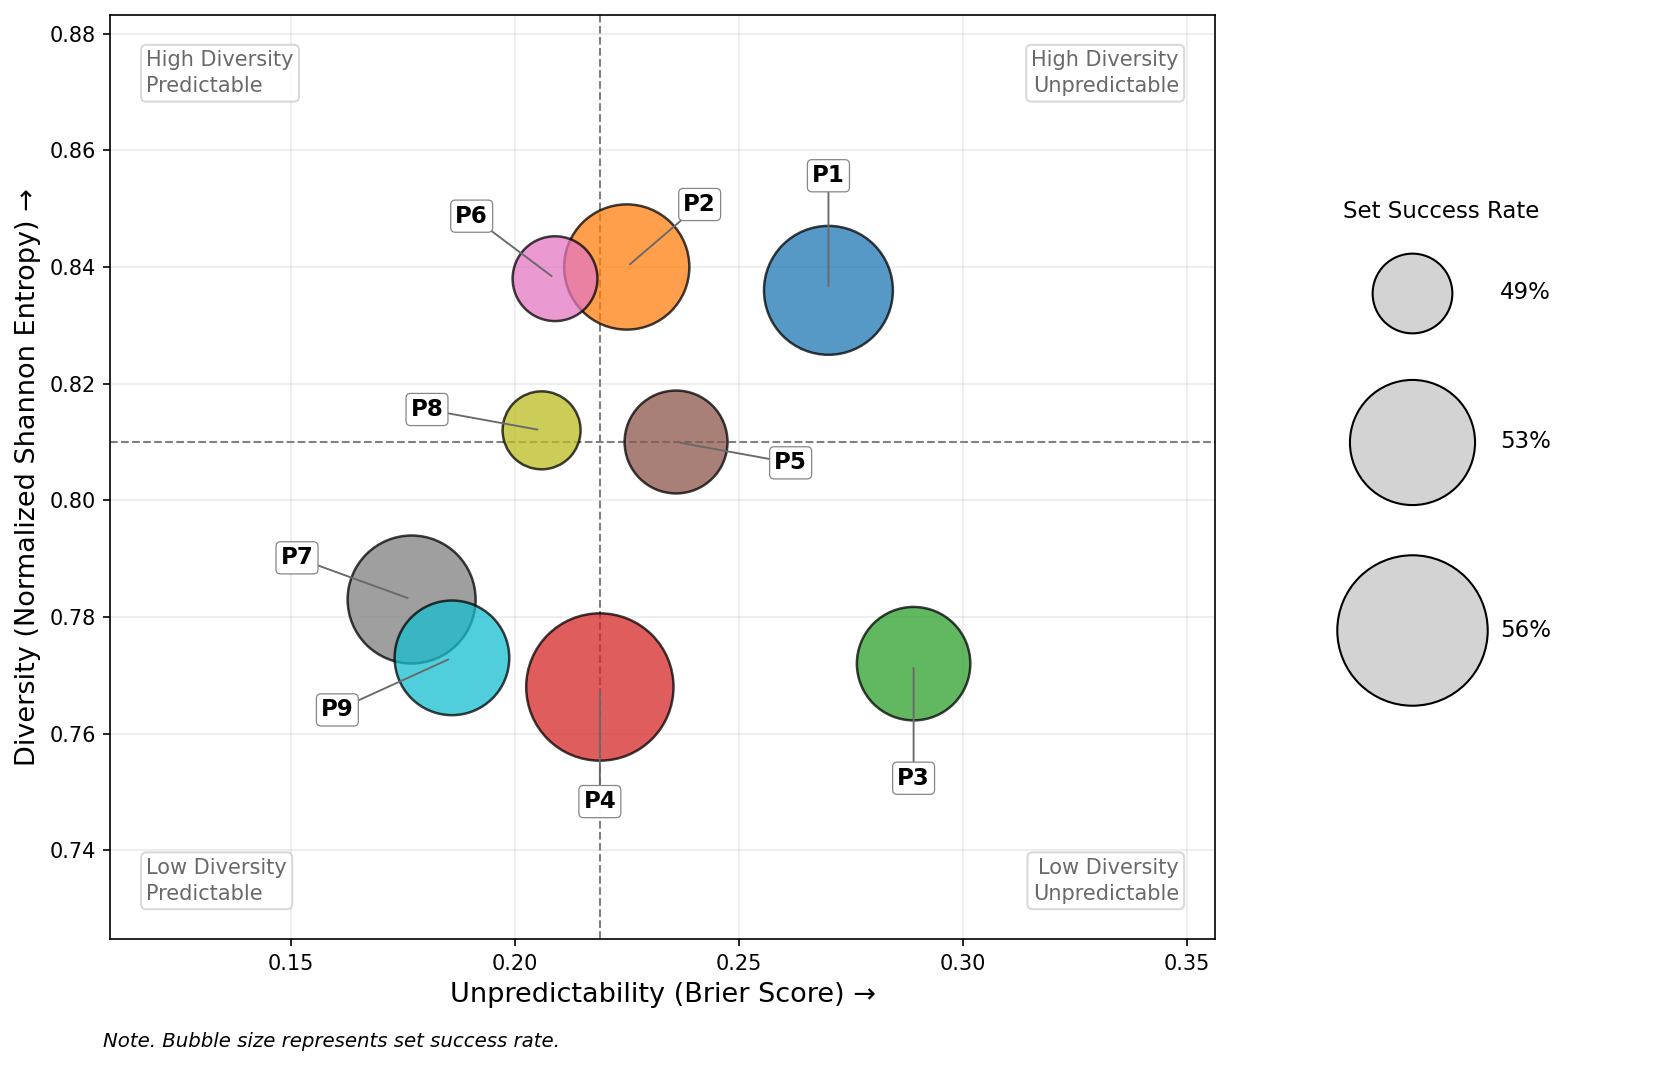

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['axes.unicode_minus'] = False
# 로컬에 Times New Roman이 있으면 아래 줄 활성화
# plt.rcParams['font.family'] = 'Times New Roman'

data = {
    'code':        ['P1','P2','P3','P4','P5','P6','P7','P8','P9'],
    'entropy_norm':[0.836, 0.840, 0.772, 0.768, 0.810, 0.838, 0.783, 0.812, 0.773],
    'brier_mean':  [0.270, 0.225, 0.289, 0.219, 0.236, 0.209, 0.177, 0.206, 0.186],
    'set_success': [53.41, 53.01, 51.80, 55.60, 50.82, 49.36, 53.31, 48.88, 51.92],
}

x = np.array(data['brier_mean'])
y = np.array(data['entropy_norm'])
size_raw = np.array(data['set_success'])
names = data['code']
sizes = 1400 + (size_raw - size_raw.min())/(size_raw.max()-size_raw.min()) * 3600

x_range, y_range = x.max()-x.min(), y.max()-y.min()
X_MIN, X_MAX = x.min()-x_range*0.6, x.max()+x_range*0.6
Y_MIN, Y_MAX = y.min()-y_range*0.6, y.max()+y_range*0.6
x_mid, y_mid = np.median(x), np.median(y)

fig, ax = plt.subplots(figsize=(9.5, 8), dpi=150)
colors = plt.cm.tab10(np.linspace(0, 1, len(names)))
ax.scatter(x, y, s=sizes, c=colors, alpha=0.75, edgecolors='black', linewidths=1.2, zorder=3)

label_offsets = {
    'P2': (35, 30), 'P6': (-40, 30), 'P1': (0, 55), 'P8': (-55, 10),
    'P5': (55, -10), 'P7': (-55, 20), 'P9': (-55, -25), 'P4': (0, -55), 'P3': (0, -55),
}
for i, name in enumerate(names):
    dx, dy = label_offsets[name]
    ax.annotate(name, (x[i], y[i]), xytext=(dx, dy), textcoords='offset points',
                ha='center', va='center', fontsize=11, fontweight='bold', zorder=5,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', lw=0.6, alpha=0.95),
                arrowprops=dict(arrowstyle='-', color='dimgray', lw=0.9, shrinkA=0, shrinkB=2))

ax.axvline(x_mid, color='gray', linestyle='--', linewidth=1, zorder=1)
ax.axhline(y_mid, color='gray', linestyle='--', linewidth=1, zorder=1)

quad_style = dict(fontsize=10, color='dimgray', linespacing=1.4,
                   bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='lightgray', alpha=0.85))
ax.text(X_MIN+0.008, Y_MAX-0.006, 'High Diversity\nPredictable', ha='left', va='top', **quad_style)
ax.text(X_MAX-0.008, Y_MAX-0.006, 'High Diversity\nUnpredictable', ha='right', va='top', **quad_style)
ax.text(X_MIN+0.008, Y_MIN+0.006, 'Low Diversity\nPredictable', ha='left', va='bottom', **quad_style)
ax.text(X_MAX-0.008, Y_MIN+0.006, 'Low Diversity\nUnpredictable', ha='right', va='bottom', **quad_style)

ax.set_xlabel('Unpredictability (Brier Score) →', fontsize=13)
ax.set_ylabel('Diversity (Normalized Shannon Entropy) →', fontsize=13)
# ax.set_title('Setter Tactical Decision-Making Profiles', fontsize=14, fontweight='bold', pad=14)

ax.set_xlim(X_MIN, X_MAX); ax.set_ylim(Y_MIN, Y_MAX)
ax.grid(True, alpha=0.25, zorder=0)

legend_vals = [49, 53, 56]
legend_sizes = [1400 + (v - size_raw.min())/(size_raw.max()-size_raw.min()) * 3600 for v in legend_vals]
radii_pts = [np.sqrt(s/np.pi) for s in legend_sizes]
fig_h_inch, legend_ax_h_frac = 8, 0.4
legend_ax_h_pts = fig_h_inch * legend_ax_h_frac * 72
y_positions, cursor = [], 1.0
for r in radii_pts:
    cursor -= (r + 8) / legend_ax_h_pts
    y_positions.append(cursor)
    cursor -= (r + 8) / legend_ax_h_pts

legend_ax = fig.add_axes([0.99, 0.3, 0.22, legend_ax_h_frac])
legend_ax.set_xlim(0, 1); legend_ax.set_ylim(0, 1); legend_ax.axis('off')
legend_ax.set_title('Set Success Rate', fontsize=11, loc='left')
for val, s, ypos in zip(legend_vals, legend_sizes, y_positions):
    legend_ax.scatter([0.22], [ypos], s=s, c='lightgray', edgecolors='black', linewidths=1, clip_on=False)
    legend_ax.text(0.5, ypos, f'{val}%', fontsize=11, va='center')

# 그림 아래 캡션(Note) - 표1과 동일한 스타일
fig.text(0.12, 0.02, 'Note. Bubble size represents set success rate.',
          fontsize=9.5, style='italic', ha='left')

plt.savefig('figure1_bubble_english_final.png', dpi=200, bbox_inches='tight')
plt.show()

#### ----------------

In [3]:
import sys
sys.path.insert(0, '.')
from dvw_batch_pipeline import run_batch, load_season_stats
import re
import pandas as pd

TARGET_SETTERS = {
    '대한항공': [2], '현대캐피탈': [3, 20], '우리카드': [2], 'KB손해보험': [2],
    '한국전력': [6], 'OK저축은행': [6], '삼성화재': [2, 3],
}

season_df, ace_df = load_season_stats('season_attack_stats.csv')
final_df, errors = run_batch(
    folder_path=r'C:\Users\SB99\Documents\volleyball_analysis\data\2025-2026 V-League(M)\Scout',
    target_setters=TARGET_SETTERS,
    pattern='*_M*.dvw',
    season_stats_csv='season_attack_stats.csv',
)

def get_jersey_number(player_id):
    if pd.isna(player_id):
        return None
    m = re.search(r'[-_](\d+)$', str(player_id))
    return int(m.group(1)[-2:]) if m else None

final_df['setter_number'] = final_df['setter'].apply(get_jersey_number)

FINAL_SETTERS = [
    ('OK저축은행', 6, '이민규'), ('우리카드', 2, '한태준'), ('KB손해보험', 2, '황택의'),
    ('한국전력', 6, '하승우'), ('대한항공', 2, '한선수'), ('현대캐피탈', 3, '황승빈'),
    ('삼성화재', 2, '도산지'), ('삼성화재', 3, '노재욱'), ('현대캐피탈', 20, '이준협'),
]
setter_lookup = {(t, n): name for t, n, name in FINAL_SETTERS}
mask = final_df.apply(lambda r: (r['team'], r['setter_number']) in setter_lookup, axis=1)
df_final = final_df[mask].copy()
df_final['setter_canonical'] = df_final.apply(lambda r: f"{r['team']}_{int(r['setter_number'])}", axis=1)
df_final['setter_name'] = df_final.apply(lambda r: setter_lookup[(r['team'], r['setter_number'])], axis=1)

print(df_final.shape)

총 126개 파일 발견
[1/126] &[20251020_1R_M01] 한국전력 vs 우리카드_건희(수현 완).dvw -> 75행
[2/126] &[20251021_1R_M02] 삼성화재 vs OK저축은행_연아(광연 완).dvw -> 209행
[3/126] &[20251022_1R_M03] 현대캐피탈 vs KB손해보험_지현(민수 완).dvw -> 200행
[4/126] &[20251023_1R_M04] 대한항공 vs 한국전력_건희(수현 완).dvw -> 145행
[5/126] &[20251024_1R_M05] 우리카드 vs OK저축은행_진솔(완).dvw -> 195행
[6/126] &[20251025_1R_M06] 삼성화재 vs 현대캐피탈_연아(완).dvw -> 163행
[7/126] &[20251026_1R_M07] KB손해보험 vs 대한항공_도윤(진솔 완).dvw -> 163행
[8/126] &[20251028_1R_M08] 우리카드 vs 삼성화재_민수(광연 완).dvw -> 114행
[9/126] &[20251029_1R_M09] 한국전력 vs 현대캐피탈_지현(도윤 완).dvw -> 180행
[10/126] &[20251030_1R_M10] KB손해보험 vs OK저축은행_진솔(완).dvw -> 147행
[11/126] &[20251031_1R_M11] 대한항공 vs 우리카드_도윤(광연 완).dvw -> 120행
[12/126] &[20251101_1R_M12] 한국전력 vs 삼성화재_지현(연아 완).dvw -> 179행
[13/126] &[20251102_1R_M13] 현대캐피탈 vs OK저축은행_지현(수현 완).dvw -> 152행
[14/126] &[20251104_1R_M14] KB손해보험 vs 우리카드_수현(광연 완).dvw -> 133행
[15/126] &[20251105_1R_M15] 삼성화재 vs 대한항공_지현(도윤 완).dvw -> 168행
[16/126] &[20251106_1R_M16] 한국전력 vs OK저축은행_건희(진솔 완).dvw 

In [3]:
import numpy as np
import pandas as pd

# 정규화 기준(zone 개수)은 전체 데이터셋 공통으로 고정 -> 세터별로 달라지면 안 됨
N_ZONES_FIXED = df_final['attack_zone'].nunique()  # 9명 전체 기준 zone 종류 수 (6이어야 정상)
print("전체 기준 zone 개수:", N_ZONES_FIXED)

def bootstrap_entropy_ci(series, n_zones_fixed, n_boot=2000, ci=95, seed=42):
    rng = np.random.default_rng(seed)
    n = len(series)
    boot_ents = []
    for _ in range(n_boot):
        resample = series.sample(n=n, replace=True, random_state=rng.integers(1e9))
        probs = resample.value_counts(normalize=True)
        # 분모를 고정값(n_zones_fixed)으로 -> 세터마다 공정하게 비교 가능
        ent = -(probs * np.log2(probs)).sum() / np.log2(n_zones_fixed)
        boot_ents.append(ent)
    boot_ents = np.array(boot_ents)
    lower = np.percentile(boot_ents, (100 - ci) / 2)
    upper = np.percentile(boot_ents, 100 - (100 - ci) / 2)
    return boot_ents.mean(), lower, upper

results = []
for setter, group in df_final.groupby('setter_canonical'):
    mean_ent, lo, hi = bootstrap_entropy_ci(group['attack_zone'], N_ZONES_FIXED)
    setter_name = group['setter_name'].iloc[0]   # groupby 안에서 바로 이름 가져오기 (인덱스 정렬 문제 없음)
    results.append({
        'setter': setter, 'name': setter_name, 'n': len(group),
        'entropy_mean': mean_ent, 'ci_95_low': lo, 'ci_95_high': hi
    })

result_df = pd.DataFrame(results).sort_values('entropy_mean', ascending=False)
print(result_df[['name', 'n', 'entropy_mean', 'ci_95_low', 'ci_95_high']].round(3))

전체 기준 zone 개수: 6
  name     n  entropy_mean  ci_95_low  ci_95_high
0  황택의  2831         0.840      0.829       0.852
4  노재욱  1159         0.838      0.820       0.855
2  한선수  2374         0.836      0.824       0.847
3  도산지  1594         0.812      0.797       0.828
1  이민규  2996         0.810      0.797       0.821
5  한태준  2832         0.783      0.768       0.797
7  이준협  1075         0.773      0.748       0.797
6  하승우  2751         0.772      0.758       0.784
8  황승빈  1787         0.768      0.749       0.788


#### BS계산 최종버전

In [11]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedGroupKFold
from catboost import CatBoostClassifier

# ============================================================
# 0. df_final이 이미 있다는 전제 (9인 세터, attack_zone 등 포함)
#    저장된 파일이 있으면 그걸 우선 불러오기 (재계산 방지)
# ============================================================
import os
CACHE_PATH = 'df_final_with_metrics.csv'

if os.path.exists(CACHE_PATH):
    print("캐시 파일 발견 -> 재계산 없이 바로 불러옵니다.")
    df_final = pd.read_csv(CACHE_PATH)
else:
    print("캐시 없음 -> 아래에서 새로 계산합니다 (df_final이 이미 메모리에 있어야 함).")

    # ------------------------------------------------------------
    # 1. 전처리 (결측치/타입 정리) - 이전에 하셨던 것과 동일
    # ------------------------------------------------------------
    df_final['settercall_type'] = df_final['settercall_type'].fillna('None')
    df_final['attacker_rt_eff_missing'] = df_final['attacker_rt_eff'].isna().astype(int)
    df_final['attacker_rt_eff'] = df_final['attacker_rt_eff'].fillna(df_final['attacker_season_pct'])
    df_final['is_repeat_route'] = pd.to_numeric(df_final['is_repeat_route'], errors='coerce').fillna(-1).astype(int)

    nullable_cols = ['possession_num', 'consecutive_toss_count', 'opp_rotation', 'ace_is_front']
    for c in nullable_cols:
        df_final[c] = pd.to_numeric(df_final[c], errors='coerce').astype('float64')

    df_final = df_final.dropna(subset=['attack_zone']).reset_index(drop=True)
    df_final['attack_zone'] = df_final['attack_zone'].astype(str)

    # ------------------------------------------------------------
    # 2. 타깃 인코딩
    # ------------------------------------------------------------
    le_target = LabelEncoder()
    y = le_target.fit_transform(df_final['attack_zone'])
    n_classes = len(le_target.classes_)

    # ------------------------------------------------------------
    # 3. 피처 구성 (기존 v1 모델: attacker_season_pct 포함)
    # ------------------------------------------------------------
    cat_cols = ['first_touch', 'point_type', 'settercall_type', 'prev_attack_result', 'setter_canonical']
    num_cols = ['score_diff', 'score_stage', 'is_clutch', 'streak_flow', 'possession_num',
                'opp_rotation', 'setter_front', 'attacker_rt_eff', 'attacker_rt_eff_missing',
                'is_repeat_route', 'consecutive_toss_count', 'touch_quality_score',
                'ace_is_front', 'attacker_season_pct']

    X_raw = df_final[cat_cols + num_cols].copy()
    for c in num_cols:
        X_raw[c] = pd.to_numeric(X_raw[c], errors='coerce')
        X_raw[c] = X_raw[c].fillna(X_raw[c].median())
    for c in cat_cols:
        X_raw[c] = X_raw[c].astype(str).fillna('Unknown')

    cat_feature_idx = [X_raw.columns.get_loc(c) for c in cat_cols]
    groups = df_final['match_id']

    # ------------------------------------------------------------
    # 4. Out-of-fold 예측 (재현성을 위해 thread_count=1로 고정)
    # ------------------------------------------------------------
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    oof_proba = np.zeros((len(y), n_classes))

    for train_idx, test_idx in sgkf.split(X_raw, y, groups=groups):
        model = CatBoostClassifier(
            iterations=300, loss_function='MultiClass', random_seed=42,
            cat_features=cat_feature_idx, verbose=False, thread_count=1
        )
        model.fit(X_raw.iloc[train_idx], y[train_idx])
        oof_proba[test_idx] = model.predict_proba(X_raw.iloc[test_idx])

    # ------------------------------------------------------------
    # 5. Brier Score 계산 및 저장
    # ------------------------------------------------------------
    y_onehot = np.eye(n_classes)[y]
    df_final['brier_score'] = np.sum((oof_proba - y_onehot) ** 2, axis=1)

    df_final.to_csv(CACHE_PATH, index=False, encoding='utf-8-sig')
    print(f"계산 완료, 저장됨: {CACHE_PATH}")

print(df_final['brier_score'].describe())

# ============================================================
# 6. 세터별 Brier Score + 부트스트랩 95% 신뢰구간
# ============================================================
def bootstrap_bs_ci(brier_series, n_boot=2000, ci=95, seed=42):
    rng = np.random.default_rng(seed)
    n = len(brier_series)
    boot_means = []
    for _ in range(n_boot):
        resample = brier_series.sample(n=n, replace=True, random_state=rng.integers(1e9))
        boot_means.append(resample.mean())
    boot_means = np.array(boot_means)
    lower = np.percentile(boot_means, (100 - ci) / 2)
    upper = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return boot_means.mean(), lower, upper

results = []
for setter, group in df_final.groupby('setter_canonical'):
    mean_bs, lo, hi = bootstrap_bs_ci(group['brier_score'])
    results.append({
        'name': group['setter_name'].iloc[0], 'n': len(group),
        'bs_mean': mean_bs, 'ci_low': lo, 'ci_high': hi
    })

result_df = pd.DataFrame(results).sort_values('bs_mean', ascending=False)
print(result_df.round(3))

캐시 없음 -> 아래에서 새로 계산합니다 (df_final이 이미 메모리에 있어야 함).
계산 완료, 저장됨: df_final_with_metrics.csv
count    19399.000000
mean         0.229122
std          0.406568
min          0.000017
25%          0.002612
50%          0.023484
75%          0.244070
max          1.985620
Name: brier_score, dtype: float64
  name     n  bs_mean  ci_low  ci_high
6  하승우  2751    0.289   0.274    0.305
2  한선수  2374    0.270   0.253    0.287
1  이민규  2996    0.236   0.221    0.251
0  황택의  2831    0.225   0.210    0.241
8  황승빈  1787    0.219   0.201    0.238
4  노재욱  1159    0.209   0.187    0.234
3  도산지  1594    0.206   0.186    0.226
7  이준협  1075    0.186   0.165    0.208
5  한태준  2832    0.177   0.163    0.192


#### 추가 분석

In [4]:
import pandas as pd

# ============================================================
# 위기대처지수
# ============================================================
crisis_mask = (df_final['score_diff'] <= -3) & (df_final['point_type'] == 'Sideout')
normal_mask = (df_final['score_diff'] > -3) & (df_final['point_type'] == 'Sideout')

crisis_success = df_final[crisis_mask].groupby('setter_canonical').apply(
    lambda g: (g['attack_result'] == '#').mean()
)
crisis_n = df_final[crisis_mask].groupby('setter_canonical').size()
normal_success = df_final[normal_mask].groupby('setter_canonical').apply(
    lambda g: (g['attack_result'] == '#').mean()
)

crisis_index = pd.DataFrame({
    '열세_사이드아웃_성공률': crisis_success,
    '평상시_사이드아웃_성공률': normal_success,
    '표본수(열세)': crisis_n,
})
crisis_index['위기대처지수'] = crisis_index['열세_사이드아웃_성공률'] - crisis_index['평상시_사이드아웃_성공률']
name_map = df_final.drop_duplicates('setter_canonical').set_index('setter_canonical')['setter_name']
crisis_index['name'] = name_map
crisis_index = crisis_index.sort_values('위기대처지수', ascending=False)
print("=== 위기대처지수 ===")
print(crisis_index[['name','표본수(열세)','열세_사이드아웃_성공률','평상시_사이드아웃_성공률','위기대처지수']].round(3))

# ============================================================
# 전술수행지수 (세터콜 활용 가치)
# ============================================================
call_success = df_final.groupby(['setter_canonical', df_final['settercall_type'].notna()]).apply(
    lambda g: (g['attack_result'] == '#').mean()
).unstack()
call_success.columns = ['콜없음_성공률', '콜있음_성공률']
call_success['전술수행지수'] = call_success['콜있음_성공률'] - call_success['콜없음_성공률']
call_success['name'] = name_map
call_success = call_success.sort_values('전술수행지수', ascending=False)
print("\n=== 전술수행지수 (콜 유무별 성공률 차이) ===")
print(call_success[['name','콜없음_성공률','콜있음_성공률','전술수행지수']].round(3))

# 콜 유형별(Middle/Shift/Other) 세부
print("\n=== 콜 유형별 성공률 ===")
call_type_success = df_final.dropna(subset=['settercall_type']).groupby(
    ['setter_canonical', 'settercall_type']
).apply(lambda g: (g['attack_result'] == '#').mean()).unstack()
call_type_success['name'] = name_map
print(call_type_success.round(3))

=== 위기대처지수 ===
                 name  표본수(열세)  열세_사이드아웃_성공률  평상시_사이드아웃_성공률  위기대처지수
setter_canonical                                                   
현대캐피탈_3           황승빈      249         0.426          0.569  -0.143
삼성화재_3            노재욱      350         0.400          0.573  -0.173
한국전력_6            하승우      434         0.380          0.579  -0.199
OK저축은행_6          이민규      449         0.354          0.564  -0.209
삼성화재_2            도산지      361         0.346          0.561  -0.215
현대캐피탈_20          이준협      161         0.354          0.571  -0.217
우리카드_2            한태준      378         0.370          0.589  -0.218
KB손해보험_2          황택의      387         0.339          0.593  -0.255
대한항공_2            한선수      225         0.276          0.597  -0.321

=== 전술수행지수 (콜 유무별 성공률 차이) ===
                 name  콜없음_성공률  콜있음_성공률  전술수행지수
setter_canonical                               
대한항공_2            한선수    0.438    0.618   0.179
한국전력_6            하승우    0.426    0.595   0.169
KB손해보험_2      

In [5]:
import numpy as np
import pandas as pd

df_side = df_final[df_final['point_type'] == 'Sideout'].copy()
df_side['success'] = (df_side['attack_result'] == '#').astype(int)

# ============================================================
# ① 컷오프 민감도 검증 (여러 기준으로 반복)
# ============================================================
print("=== 컷오프별 위기대처지수 순위 비교 ===")
sensitivity = {}
for cutoff in [-2, -3, -4, -5]:
    crisis = df_side[df_side['score_diff'] <= cutoff]
    normal = df_side[df_side['score_diff'] > cutoff]
    idx = crisis.groupby('setter_canonical')['success'].mean() - normal.groupby('setter_canonical')['success'].mean()
    sensitivity[f'cutoff_{cutoff}'] = idx

sens_df = pd.DataFrame(sensitivity)
sens_df['name'] = name_map
print(sens_df.round(3))

# 순위 일관성 확인 (Kendall's W 또는 각 컷오프 간 상관)
from scipy.stats import spearmanr
print("\n=== 컷오프 간 순위 상관 (cutoff_-3 vs 나머지) ===")
for c in ['cutoff_-2','cutoff_-4','cutoff_-5']:
    rho, p = spearmanr(sens_df['cutoff_-3'], sens_df[c])
    print(f"-3 vs {c}: rho={rho:.3f}")

# ============================================================
# ② 회귀 기반 접근 (score_diff -> success, 세터별 기울기)
# ============================================================
from sklearn.linear_model import LogisticRegression

print("\n=== 세터별 회귀 기울기 (score_diff가 성공률에 미치는 영향) ===")
slopes = []
for setter, group in df_side.groupby('setter_canonical'):
    X = group[['score_diff']].values
    y = group['success'].values
    if y.sum() == 0 or y.sum() == len(y):  # 성공/실패가 한쪽으로 쏠린 경우 방지
        continue
    model = LogisticRegression()
    model.fit(X, y)
    slopes.append({'setter_canonical': setter, 'name': group['setter_name'].iloc[0],
                    'slope': model.coef_[0][0], 'n': len(group)})

slope_df = pd.DataFrame(slopes).sort_values('slope', ascending=False)
print(slope_df.round(4))
print("\n(기울기가 클수록: 점수차가 좁혀질 때 성공률 민감도가 크다 = 위기 영향을 많이 받음)")

# ============================================================
# ③ 부트스트랩 신뢰구간 (기존 이진 지수, cutoff=-3 기준)
# ============================================================
def bootstrap_crisis_index(setter_data_crisis, setter_data_normal, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    boot_diffs = []
    for _ in range(n_boot):
        c_resample = setter_data_crisis.sample(n=len(setter_data_crisis), replace=True, random_state=rng.integers(1e9))
        n_resample = setter_data_normal.sample(n=len(setter_data_normal), replace=True, random_state=rng.integers(1e9))
        boot_diffs.append(c_resample['success'].mean() - n_resample['success'].mean())
    boot_diffs = np.array(boot_diffs)
    return boot_diffs.mean(), np.percentile(boot_diffs, 2.5), np.percentile(boot_diffs, 97.5)

results = []
crisis_all = df_side[df_side['score_diff'] <= -3]
normal_all = df_side[df_side['score_diff'] > -3]
for setter in df_side['setter_canonical'].unique():
    c = crisis_all[crisis_all['setter_canonical'] == setter]
    n = normal_all[normal_all['setter_canonical'] == setter]
    if len(c) < 10 or len(n) < 10:
        continue
    mean_diff, lo, hi = bootstrap_crisis_index(c, n)
    results.append({'setter': setter, 'name': c['setter_name'].iloc[0],
                     'n_crisis': len(c), 'index_mean': mean_diff, 'ci_low': lo, 'ci_high': hi})

boot_result = pd.DataFrame(results).sort_values('index_mean', ascending=False)
print("\n=== 위기대처지수 부트스트랩 95% CI ===")
print(boot_result.round(3))

=== 컷오프별 위기대처지수 순위 비교 ===
                  cutoff_-2  cutoff_-3  cutoff_-4  cutoff_-5 name
setter_canonical                                                 
KB손해보험_2             -0.248     -0.255     -0.264     -0.292  황택의
OK저축은행_6             -0.227     -0.209     -0.252     -0.311  이민규
대한항공_2               -0.294     -0.321     -0.329     -0.285  한선수
삼성화재_2               -0.200     -0.215     -0.184     -0.198  도산지
삼성화재_3               -0.225     -0.173     -0.214     -0.172  노재욱
우리카드_2               -0.265     -0.218     -0.282     -0.314  한태준
한국전력_6               -0.210     -0.199     -0.210     -0.223  하승우
현대캐피탈_20             -0.247     -0.217     -0.258     -0.249  이준협
현대캐피탈_3              -0.176     -0.143     -0.192     -0.155  황승빈

=== 컷오프 간 순위 상관 (cutoff_-3 vs 나머지) ===
-3 vs cutoff_-2: rho=0.867
-3 vs cutoff_-4: rho=0.800
-3 vs cutoff_-5: rho=0.700

=== 세터별 회귀 기울기 (score_diff가 성공률에 미치는 영향) ===
  setter_canonical name   slope     n
5           우리카드_2  한태준  0.2007  2336
2    

In [3]:
import pandas
import numpy
import scipy
import sklearn
import catboost
import xgboost
import matplotlib
import pingouin

print("pandas", pandas.__version__)
print("numpy", numpy.__version__)
print("scipy", scipy.__version__)
print("scikit-learn", sklearn.__version__)
print("catboost", catboost.__version__)
print("xgboost", xgboost.__version__)
print("matplotlib", matplotlib.__version__)
print("pingouin", pingouin.__version__)

pandas 2.1.1
numpy 1.26.4
scipy 1.17.1
scikit-learn 1.8.0
catboost 1.2.10
xgboost 3.4.1
matplotlib 3.10.8
pingouin 0.6.1
